In [1]:
#%pip install pandas
import pandas as pd

In [2]:
inventory = pd.read_csv("../data/processed/drop_cases_inventory.csv")
price_history = pd.read_csv("../data/processed/drop_cases_prices.csv")

In [3]:
inventory.info()
inventory.head()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   case_name  13 non-null     str  
 1   quantity   13 non-null     int64
dtypes: int64(1), str(1)
memory usage: 340.0 bytes


,case_name,quantity
0,Dream & Nightmares,16
1,Fever,35
2,Fracture,9
3,Gallery,6
4,Horizon,1


In [4]:
price_history.info()
price_history.head()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        146 non-null    str    
 1   case_name   146 non-null    str    
 2   unit_price  146 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.6 KB


,date,case_name,unit_price
0,2025-09-17,Dream & Nightmares,1.65
1,2025-10-27,Dream & Nightmares,1.84
2,2025-11-22,Dream & Nightmares,1.66
3,2025-12-03,Dream & Nightmares,1.52
4,2025-12-18,Dream & Nightmares,1.46


In [5]:
price_history_with_inventory = price_history.merge(
    inventory,
    on="case_name",
    how="left"
)

price_history_with_inventory.head()

,date,case_name,unit_price,quantity
0,2025-09-17,Dream & Nightmares,1.65,16
1,2025-10-27,Dream & Nightmares,1.84,16
2,2025-11-22,Dream & Nightmares,1.66,16
3,2025-12-03,Dream & Nightmares,1.52,16
4,2025-12-18,Dream & Nightmares,1.46,16


In [6]:
price_history_with_inventory["total_value"] = (
    price_history_with_inventory["unit_price"]
    * price_history_with_inventory["quantity"]
)

price_history_with_inventory

,date,case_name,unit_price,quantity,total_value
0,2025-09-17,Dream & Nightmares,1.65,16,26.40
1,2025-10-27,Dream & Nightmares,1.84,16,29.44
2,2025-11-22,Dream & Nightmares,1.66,16,26.56
3,2025-12-03,Dream & Nightmares,1.52,16,24.32
4,2025-12-18,Dream & Nightmares,1.46,16,23.36
...,...,...,...,...,...
141,2026-03-31,Snakebite,0.76,7,5.32
142,2026-05-05,Snakebite,0.85,7,5.95
143,2026-06-11,Snakebite,0.74,7,5.18
144,2026-07-01,Snakebite,0.66,7,4.62


In [7]:
price_history["date"] = pd.to_datetime(price_history["date"])
price_history = price_history.sort_values("date")

In [8]:
dream = price_history[
    price_history["case_name"] == "Dream & Nightmares"
].copy()

dream

,date,case_name,unit_price
0,2025-09-17,Dream & Nightmares,1.65
1,2025-10-27,Dream & Nightmares,1.84
2,2025-11-22,Dream & Nightmares,1.66
3,2025-12-03,Dream & Nightmares,1.52
4,2025-12-18,Dream & Nightmares,1.46
5,2026-01-14,Dream & Nightmares,1.41
6,2026-02-13,Dream & Nightmares,1.45
7,2026-03-03,Dream & Nightmares,1.55
8,2026-03-13,Dream & Nightmares,1.68
9,2026-03-31,Dream & Nightmares,1.88


In [9]:
#%pip install matplotlib.pyplot
#%pip install seaborn

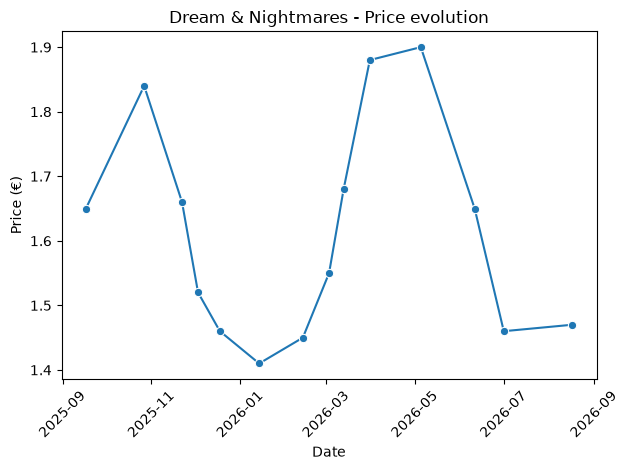

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(
    data=dream,
    x="date",
    y="unit_price",
    marker="o"
)

plt.title("Dream & Nightmares - Price evolution")
plt.xlabel("Date")
plt.ylabel("Price (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
dream["performance"] = (
    dream["unit_price"] / dream["unit_price"].iloc[0]
) * 100

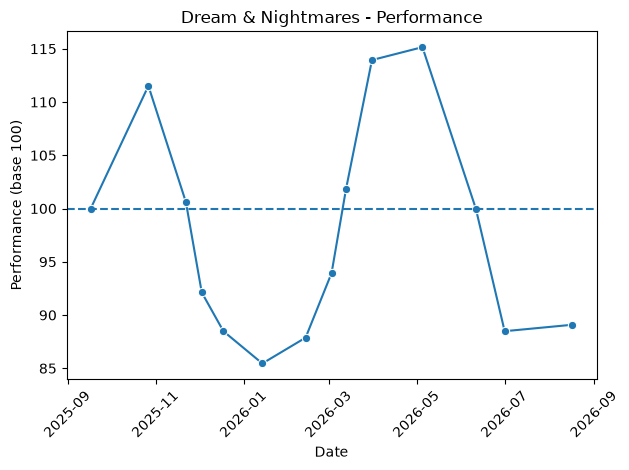

In [12]:
sns.lineplot(
    data=dream,
    x="date",
    y="performance",
    marker="o"
)

plt.axhline(100, linestyle="--")

plt.title("Dream & Nightmares - Performance")
plt.xlabel("Date")
plt.ylabel("Performance (base 100)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()